In [ ]:
# !pip install segmentation_models_pytorch

In [3]:
# IMPORTING NECESSARY LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

In [4]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [5]:
# Prevents OpenCV from using multiple threads to avoid RAM leaks with PyTorch

cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

In [6]:
# CHECKING THE SHAPE OF INPUT IMAGE AND ITS CORRESPONDING MASK

image = cv2.imread("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/images/brisc2025_train_00001_gl_ax_t1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = cv2.imread("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_00001_gl_ax_t1.png", 0)

print("IMAGE SHAPE:", image.shape)
print("MASK SHAPE:", mask.shape)

IMAGE SHAPE: (512, 512, 3)
MASK SHAPE: (512, 512)


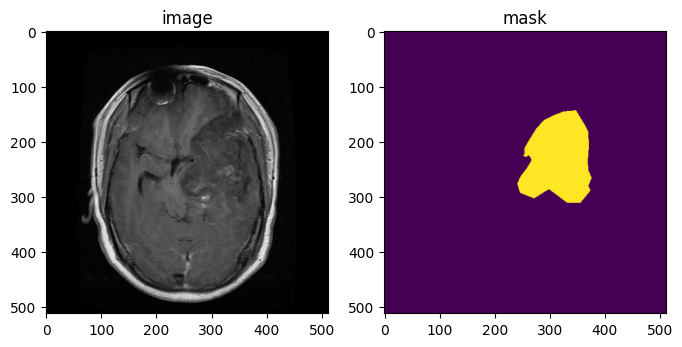

In [7]:
# PLOTTING A SAMPLE IMG,MASK PAIR

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("mask")

plt.show()

In [8]:
# JUST VERIFYING THE PIXEL VALUES (ANOMALITIES IF THERE)

mask = cv2.imread("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_00001_gl_ax_t1.png", cv2.IMREAD_GRAYSCALE)

classes = np.unique(mask)

print("Unique class values:", classes)
print("Number of classes:", len(classes))

Unique class values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]
Number of classes: 16


[0 1]


Text(0.5, 1.0, 'mask')

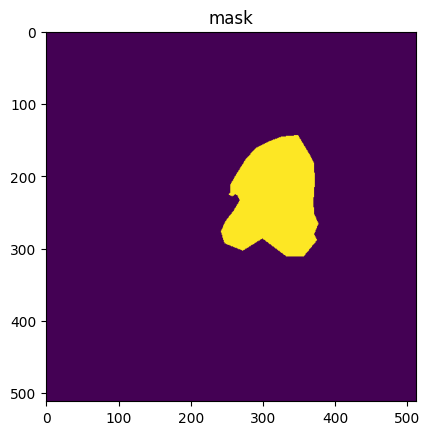

In [9]:
mask = (mask>127).astype(np.uint8)
print(np.unique(mask))
plt.imshow(mask)
plt.title("mask")

In [10]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [11]:
IMG_SIZE = 384
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_IMG_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/images"
TRAIN_MASK_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train/masks"

TEST_IMG_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images"
TEST_MASK_DIR = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/masks"

In [12]:
# USUSAL TRAIN, TEST, SPLIT TO GET A VALIDATION SET

from sklearn.model_selection import train_test_split

all_train_images = sorted(os.listdir(TRAIN_IMG_DIR))

train_images, val_images = train_test_split(
    all_train_images,
    test_size=0.2,
    random_state=42
)

In [13]:
train_images[0]

'brisc2025_train_03706_pi_ax_t1.jpg'

In [14]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# DEFINING TRANSFORMATIONS:

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
    A.GridDistortion(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_812/4094162545.py:13: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),


In [15]:
from torch.utils.data import Dataset, DataLoader

# DEFINING DATASET CLASS

class SegDataset(Dataset):
    
    def __init__(self, img_dir, mask_dir, images=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        if images is not None:
            self.images = images
        else:
            self.images = sorted(os.listdir(img_dir))
            
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg",".png"))

        #IMAGE
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        #MASK
        mask = cv2.imread(mask_path, 0)
        mask = (mask>127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float()
        
        return image, mask

In [16]:
# STORING TRAIN, VAL, AND TEST DATASETS

train_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_images, train_transform)

val_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, val_images, val_transform)

test_dataset = SegDataset(TEST_IMG_DIR, TEST_MASK_DIR, None, test_transform)

In [17]:
# PRINTING THE SHAPES OF A PAIR OF IMG, MASK FROM TRAIN-DATASET, JUST FOR SANITY CHECK!

sample_img, sample_mask = train_dataset[0]

print(sample_img.shape)
print(sample_mask.shape)

torch.Size([3, 384, 384])
torch.Size([1, 384, 384])


In [18]:
# DEFINING AND STORING TRAIN, VAL AND TEST LOADERS!

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=4, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=4, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=4, drop_last=True)

In [19]:
# DEFINING COMBINED LOSS FUNCTION WITH MORE WEIGHTAGE GIVEN TO THE DICE LOSS

# Dice loss 
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)

# Focal loss
focal_loss = smp.losses.FocalLoss(mode="binary")

# Combined loss
def loss_fn(pred, target):
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)

In [20]:
# DEFINING THE IOU METRIC

def iou_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred>threshold).float()

    intersection = (pred * target).sum()
    union = (pred + target - pred * target).sum()

    return (intersection + 1e-6) / (union + 1e-6)

In [21]:
# DEFINING A GENERIC TRAINING METHOD FOR TRAINING MODELS!

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    model_name
):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.8,
        patience=2
    )
    
    print(f"TRAINING {model_name} ...\n")
    
    best_val_iou = 0.0
    
    for epoch in range(epochs):
    
        # -------- TRAINING --------
        model.train()
        train_loss = 0
        train_iou = 0
    
        for images, masks in train_loader:
    
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
    
            # FORWARD PROP
            outputs = model(images.contiguous())
            # CALCULATING LOSS
            loss = loss_fn(outputs, masks)
            # CLEARING PREVIOUS GRADIENTS
            optimizer.zero_grad()
            # CALCULATING NEW GRADIENTS
            loss.backward()
            # UPDATING PARAMETERS
            optimizer.step()
    
            train_loss += loss.item()
            train_iou += iou_score(outputs.detach(), masks).item()
    
        train_loss /= len(train_loader)
        train_iou /= len(train_loader)
    
        # -------- VALIDATION --------
        model.eval()
        val_loss = 0
        val_iou = 0
    
        with torch.no_grad():
    
            for images, masks in val_loader:
    
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
    
                # FORWARD PROP
                outputs = model(images)
                # CALCULATING LOSS
                loss = loss_fn(outputs, masks)
    
                val_loss += loss.item()
                val_iou += iou_score(outputs, masks).item()
    
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        scheduler.step(val_iou)
    
        current_lr = optimizer.param_groups[0]['lr']
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train IoU: {train_iou:.4f} | "
            f"Val IoU: {val_iou:.4f} | "
            f"LR: {current_lr:.6f}"
        )
    
        # SAVING BEST MODEL BASED ON VALIDATION IOU
        if val_iou > best_val_iou:
    
            print(
                f"Validation IoU improved "
                f"({best_val_iou:.4f} → {val_iou:.4f}).\nSaving the model..."
            )
    
            torch.save({
                'epoch': epoch + 1,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_iou': train_iou,
                'val_iou': val_iou
            }, f"{model_name}.pth")
    
            best_val_iou = val_iou

In [ ]:
# DEFINING A GENERIC EVALUATION METHOD FOR EVALUATING MODELS!

def evaluate_model(
    model,
    test_loader,
    model_name
):
    
    model.eval()

    test_loss = 0
    test_iou = 0

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            # FORWARD PROP
            outputs = model(images)
            # LOSS CALCULATION
            loss = loss_fn(outputs, masks)

            test_loss += loss.item()
            test_iou += iou_score(outputs, masks).item()

    test_loss /= len(test_loader)
    test_iou /= len(test_loader)

    print(f"{model_name} EVALUATION RESULTS: \n")
    
    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test IoU: {test_iou:.4f}"
    )

    return test_loss, test_iou

In [ ]:
# DEFINING A GENERIC VISUALIZATION METHOD FOR DISPLAYING MODELS' PREDICTIONS SIDE BY SIDE!

def display_preds(model1, model2, model_name1, model_name2, test_loader, threshold=0.2, min_iou=0.90):

    model1.eval()
    model2.eval()

    MEAN = np.array([0.485, 0.456, 0.406])
    STD  = np.array([0.229, 0.224, 0.225])

    max_images = 20
    shown = 0

    with torch.no_grad():
        for images, masks in test_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits1 = model1(images)
            logits2 = model2(images)

            pred1_disp = (torch.sigmoid(logits1) > threshold).float().cpu()
            pred2_disp = (torch.sigmoid(logits2) > threshold).float().cpu()

            images = images.cpu()
            masks = masks.cpu()
            logits1 = logits1.cpu() 
            logits2 = logits2.cpu()

            for b in range(images.size(0)):

                if shown >= max_images:
                    return

                iou1 = iou_score(logits1[b], masks[b], threshold=threshold)
                iou2 = iou_score(logits2[b], masks[b], threshold=threshold)

                if iou1 < min_iou and iou2 < min_iou:
                    continue

                img = images[b].permute(1,2,0).numpy()

                # DE-NORMALIZING THE IMAGE 
                img = (img * STD) + MEAN
                img = np.clip(img, 0, 1)

                gt = masks[b].squeeze().numpy()
                p1 = pred1_disp[b].squeeze().numpy()
                p2 = pred2_disp[b].squeeze().numpy()

                plt.figure(figsize=(20,5))

                plt.subplot(1,4,1)
                plt.imshow(img)
                plt.title("Image")
                plt.axis("off")

                plt.subplot(1,4,2)
                plt.imshow(gt, cmap="gray")
                plt.title("GT")
                plt.axis("off")

                plt.subplot(1,4,3)
                plt.imshow(p1, cmap="gray")
                plt.title(f"{model_name1} | IoU {iou1:.3f}")
                plt.axis("off")

                plt.subplot(1,4,4)
                plt.imshow(p2, cmap="gray")
                plt.title(f"{model_name2} | IoU {iou2:.3f}")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1


**UNET TRAINING...**

In [ ]:
# DEFINING THE UNET MODEL

unet = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

unet = unet.to(DEVICE)

if torch.cuda.device_count() > 1:
    unet = nn.DataParallel(unet)

In [ ]:
# TRAINING THE UNET MODEL AND SAVING THE BEST VERSION OF IT

train_model(
    model=unet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    model_name="U-Net_efficientnetb3_continue"
)

In [ ]:
# CHECKPOINT TO LOAD THE BEST UNET MODEL

checkpoint1 = torch.load("/kaggle/input/datasets/mubeenakhund/mubeen-2-un/U-Net_efficientnetb3_continue.pth", map_location=DEVICE)

In [ ]:
# LOADING THE BEST UNET MODEL SAVED

unet.load_state_dict(checkpoint1['model_state'])

<All keys matched successfully>

In [ ]:
# EVALUATING THE BEST UNET MODEL

unet_loss, unet_iou = evaluate_model(unet, test_loader, "U-Net_efficientnetb3")

U-Net_efficientnetb3 EVALUATION RESULTS: 

Test Loss: 0.0735 | Test IoU: 0.8120


**UNET++ TRAINING...**

In [ ]:
# DEFINING THE UNET++ MODEL

unetpp = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

unetpp = unetpp.to(DEVICE)

if torch.cuda.device_count() > 1:
    unetpp = nn.DataParallel(unetpp)

In [ ]:
# TRAINING THE UNET++ MODEL AND SAVING THE BEST VERSION OF IT

train_model(
    model=unetpp,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    model_name="U-Netpp_efficientnetb3_continue_pp",
)

In [ ]:
# CHECKPOINT TO LOAD THE BEST UNET++ MODEL

checkpoint2 = torch.load("/kaggle/input/datasets/mubeenakhund/mubeen-1-pp/U-Netpp_efficientnetb3_continue_pp.pth", map_location=DEVICE)

In [ ]:
# LOADING THE BEST UNET++ MODEL

unetpp.load_state_dict(checkpoint2['model_state'])

<All keys matched successfully>

In [ ]:
# EVALUATING THE BEST UNET++ MODEL

unetpp_loss, unetpp_iou = evaluate_model(unetpp, test_loader, "U-Netpp_efficientnetb3")

U-Netpp_efficientnetb3 EVALUATION RESULTS: 

Test Loss: 0.0698 | Test IoU: 0.8212


**DISPLAYING THE PREDICTIONS (UNET / UNET++) SIDE BY SIDE**

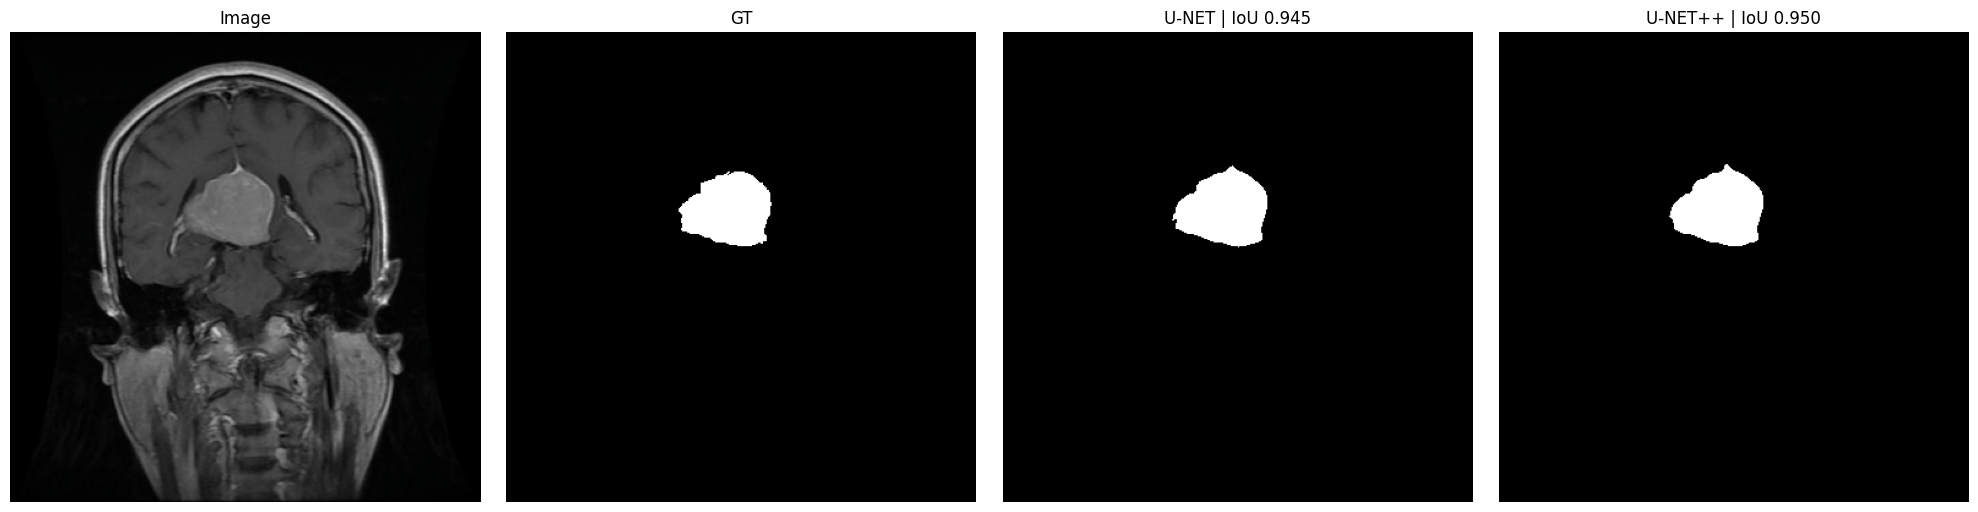

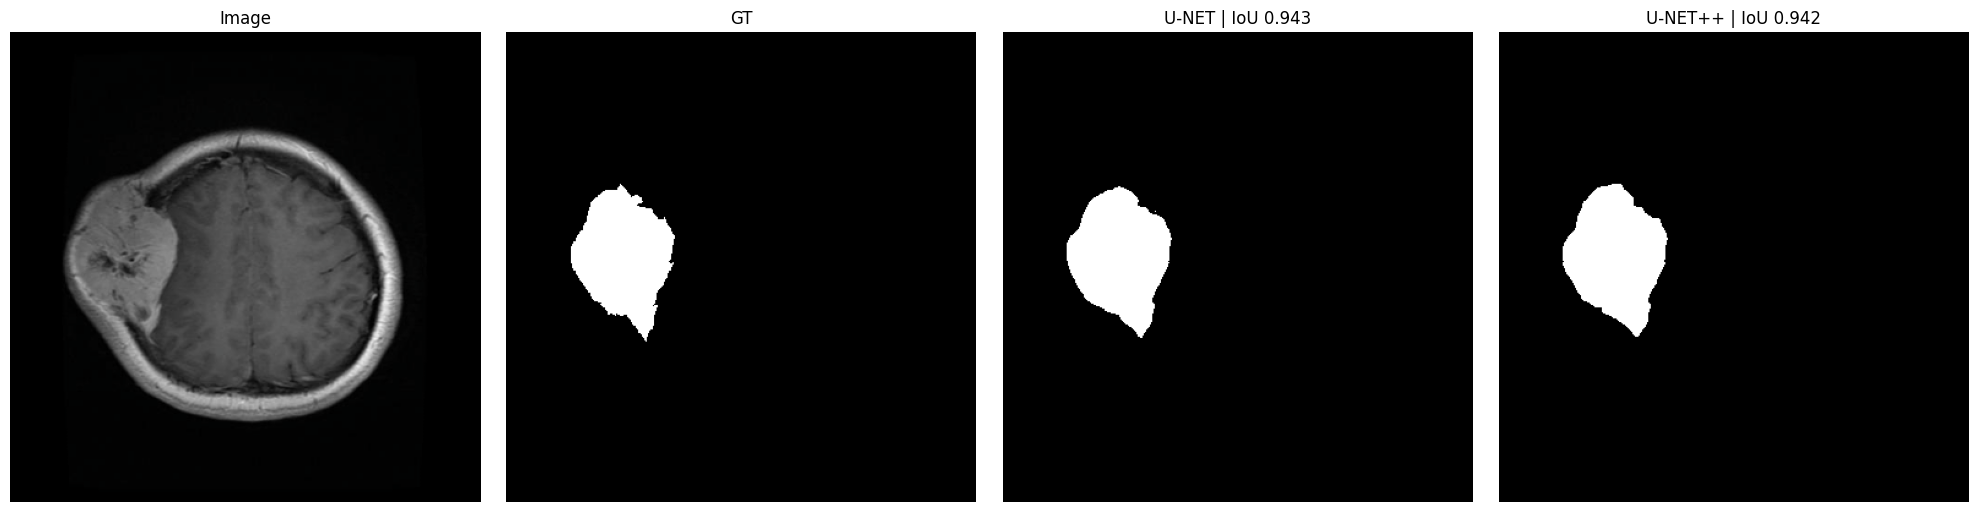

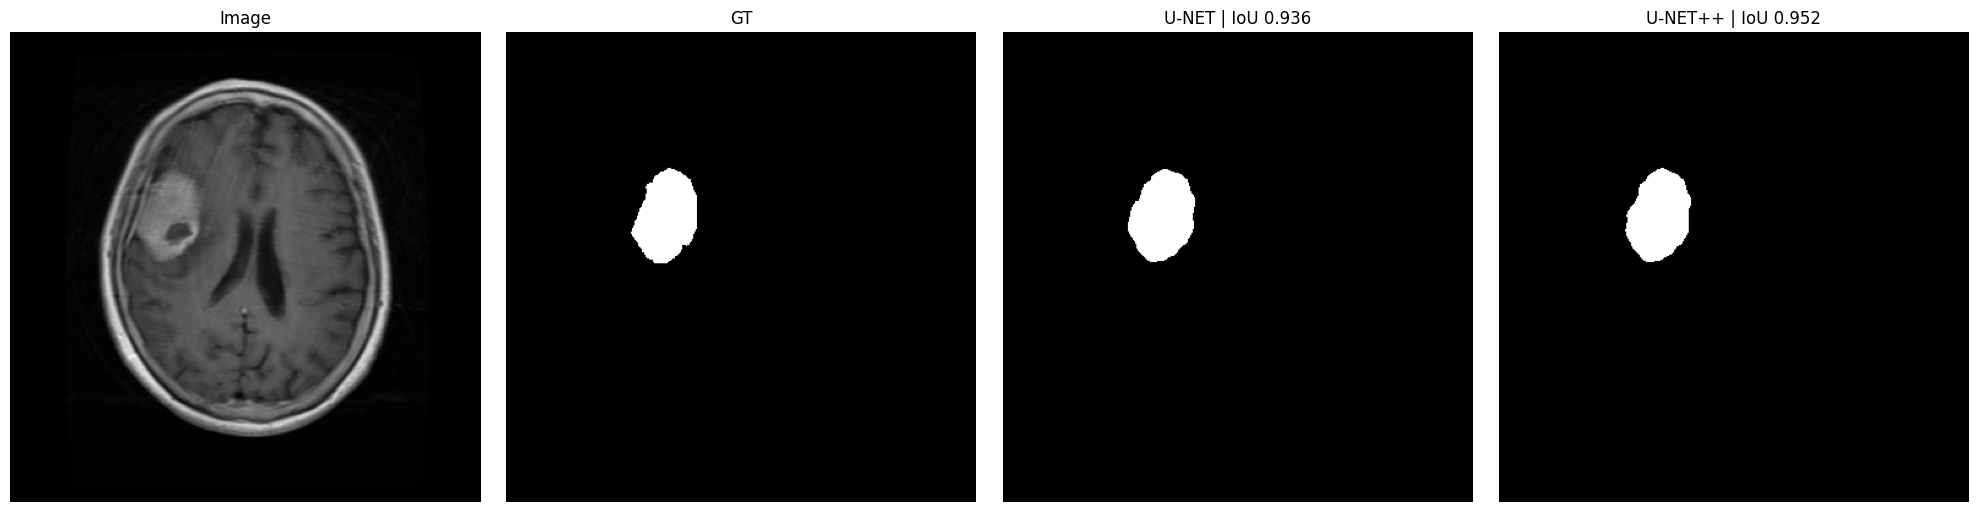

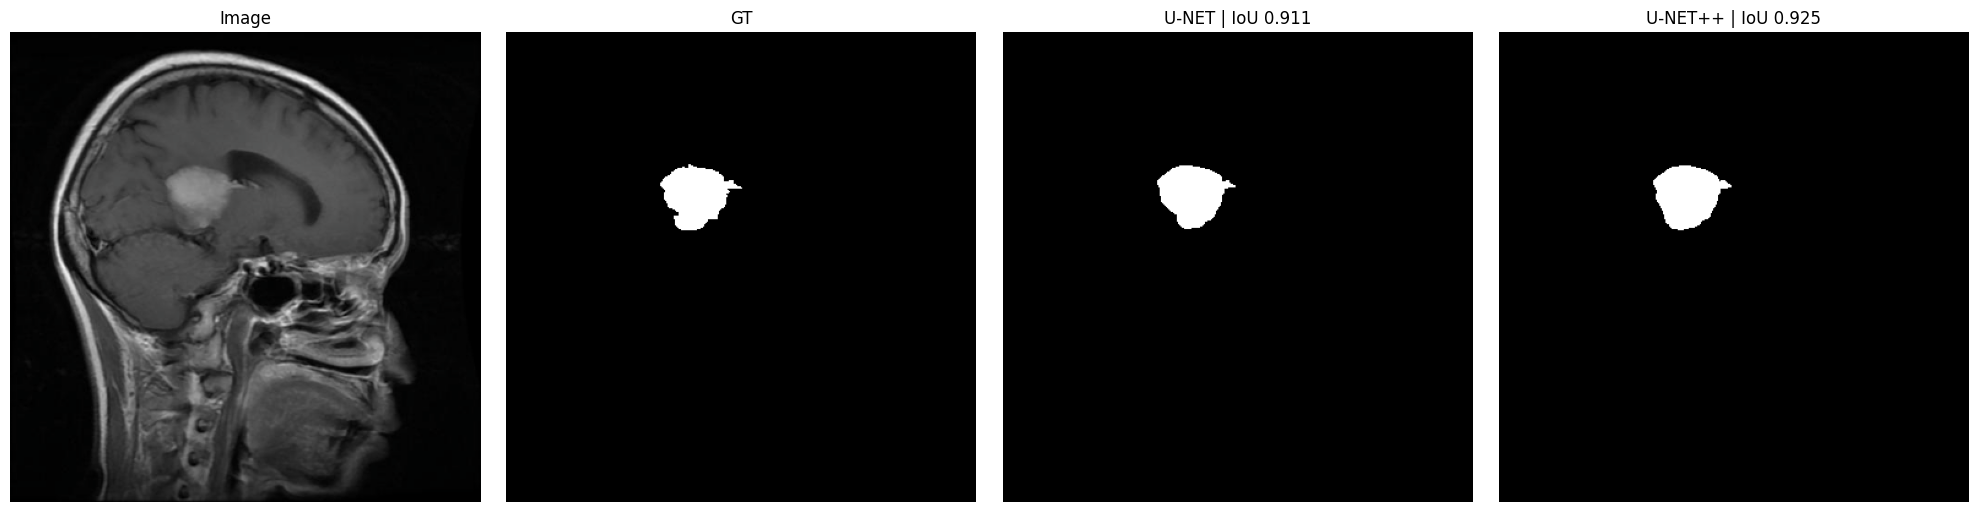

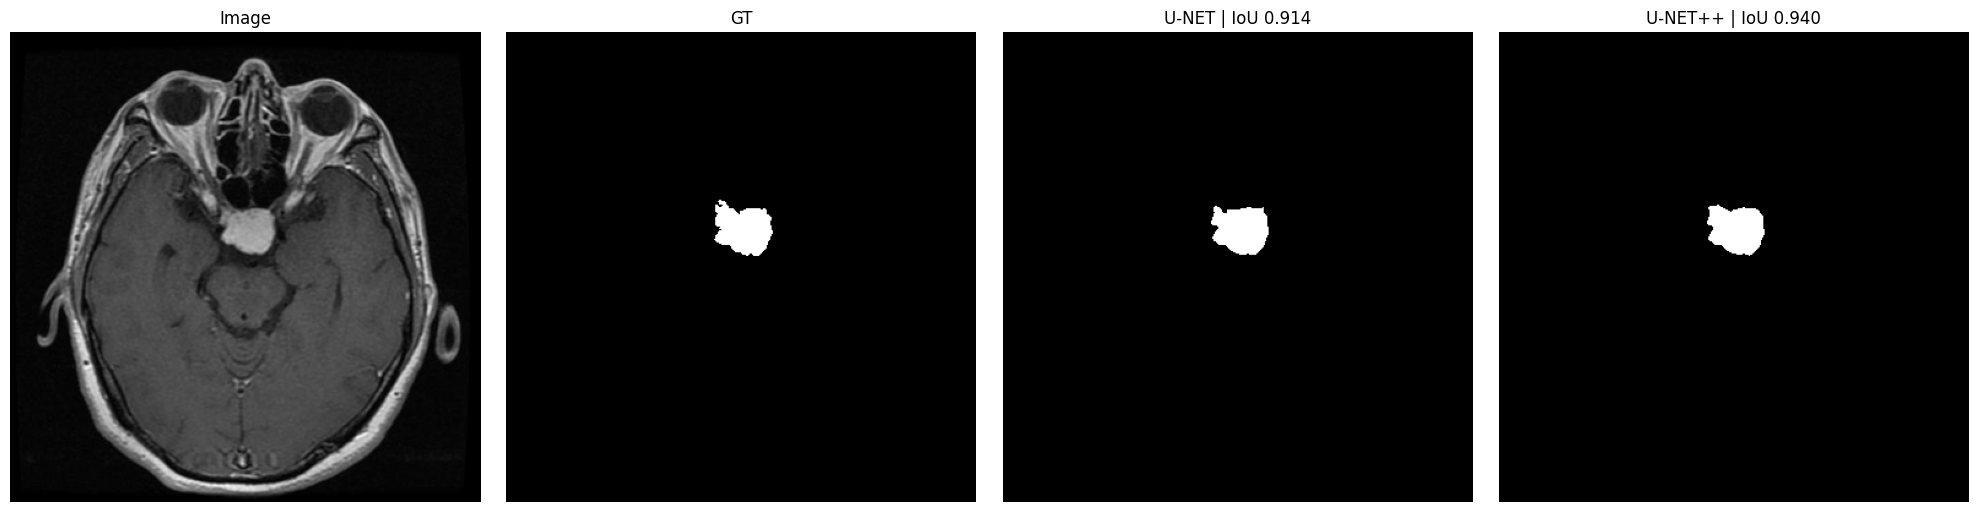

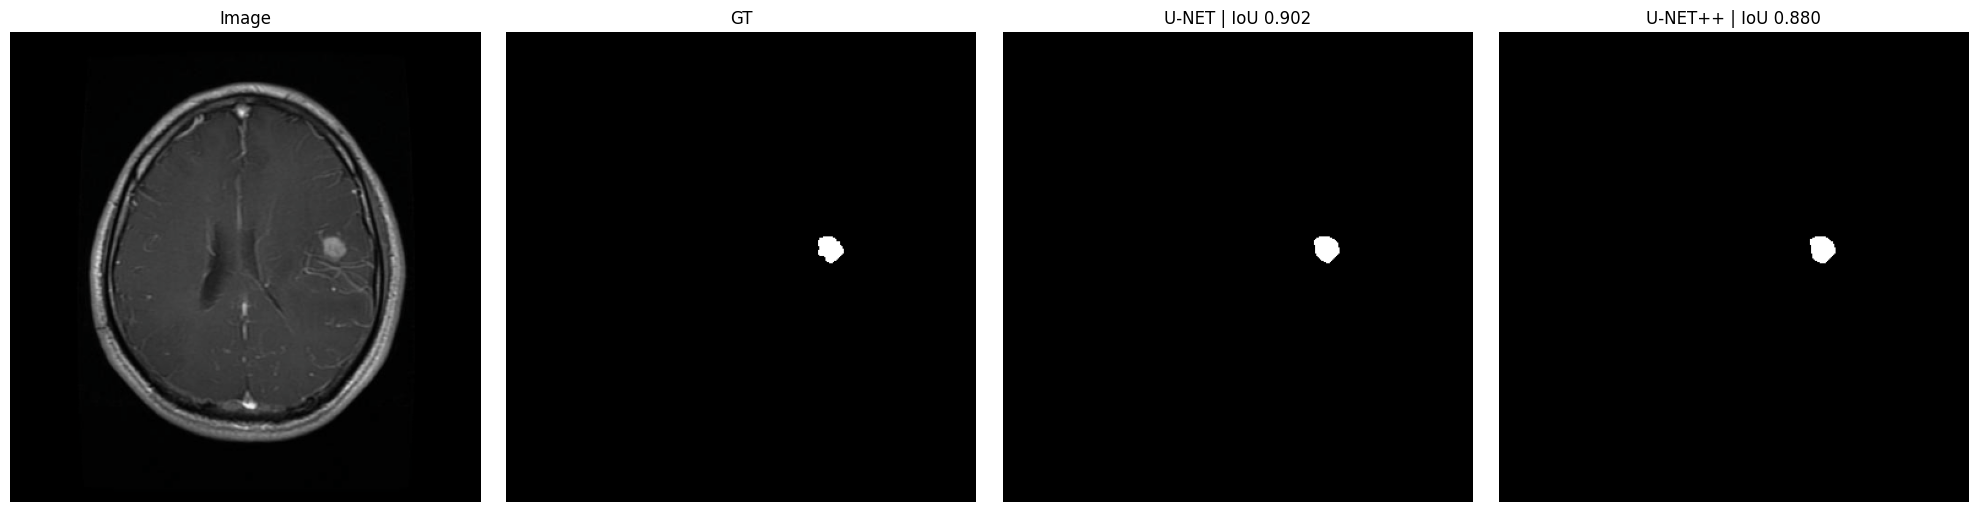

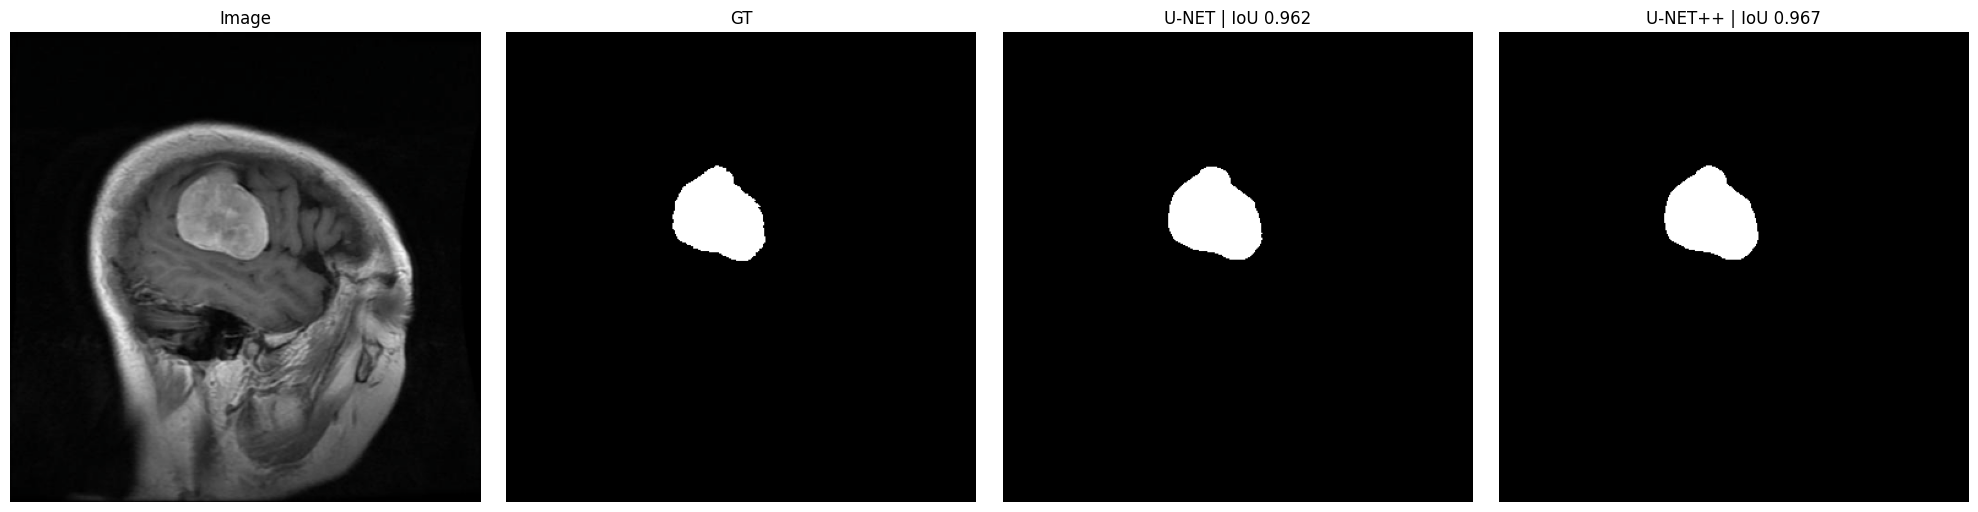

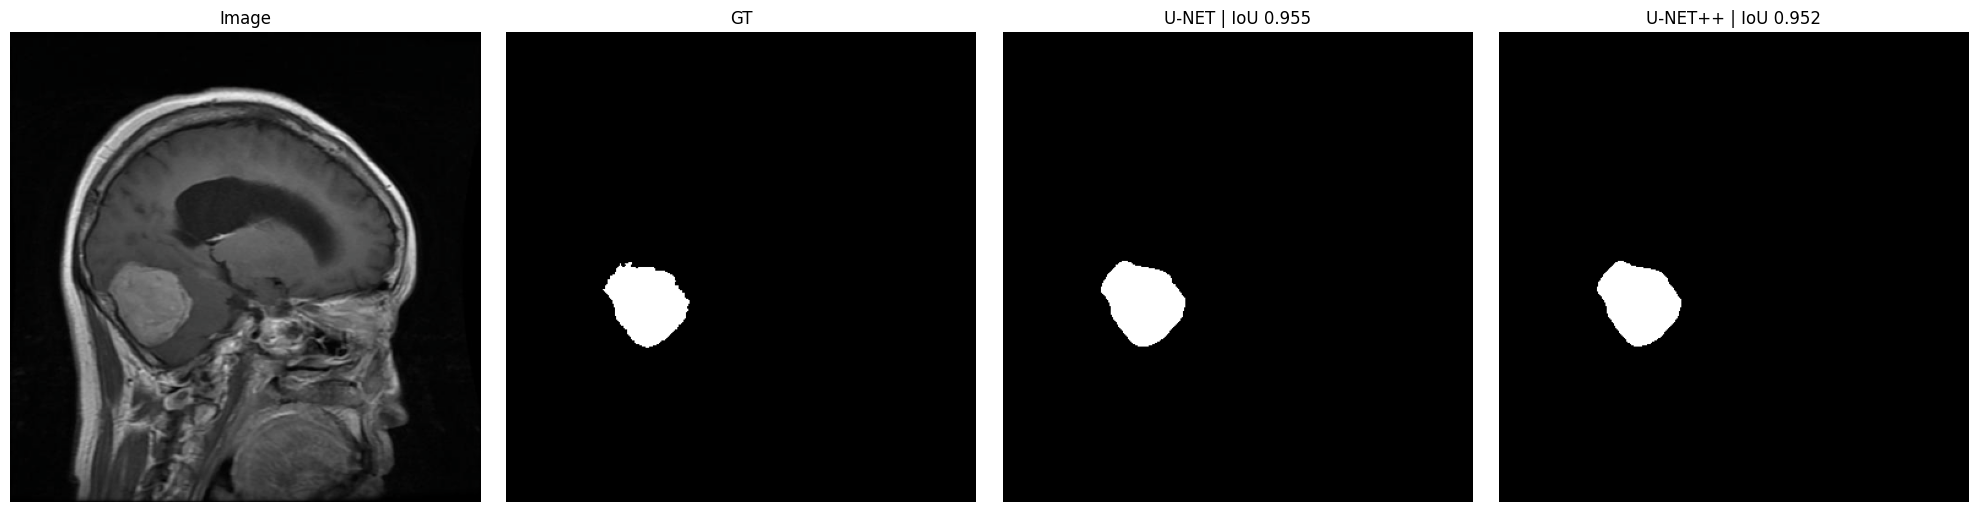

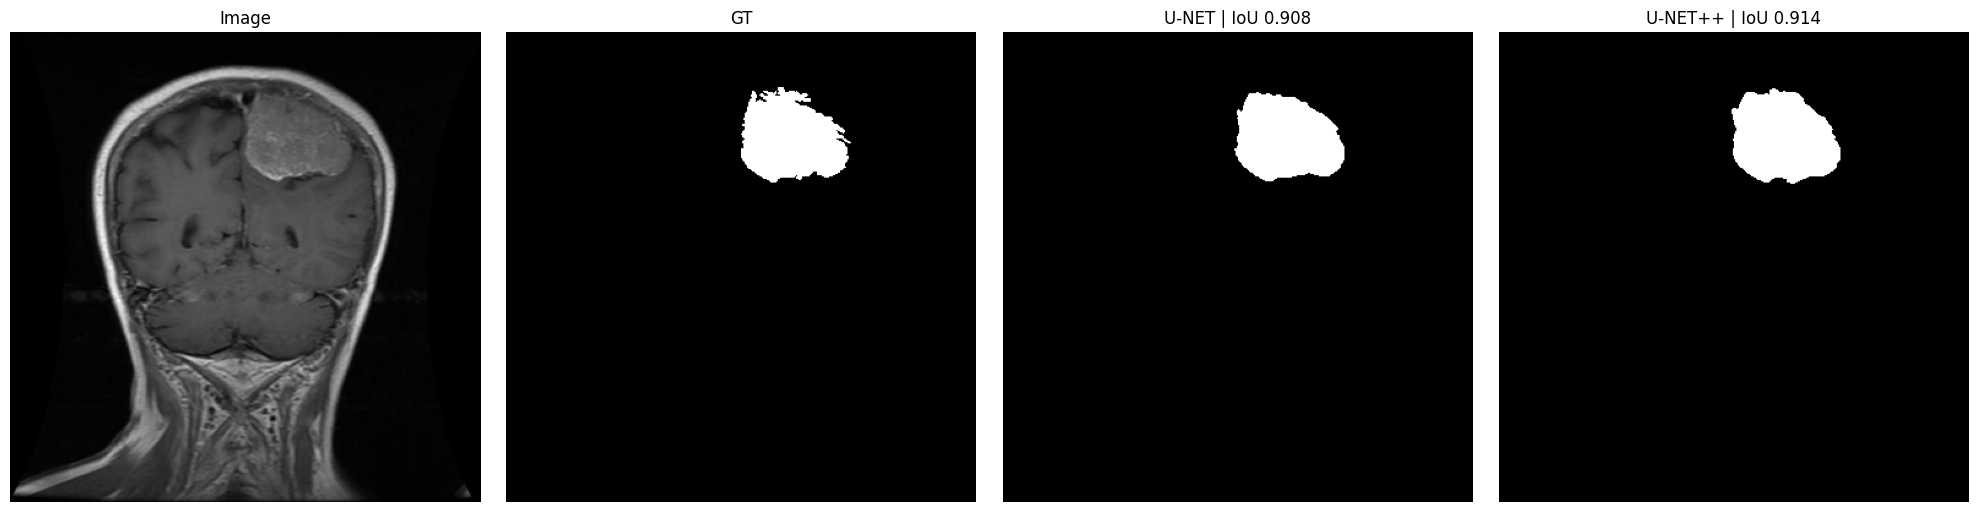

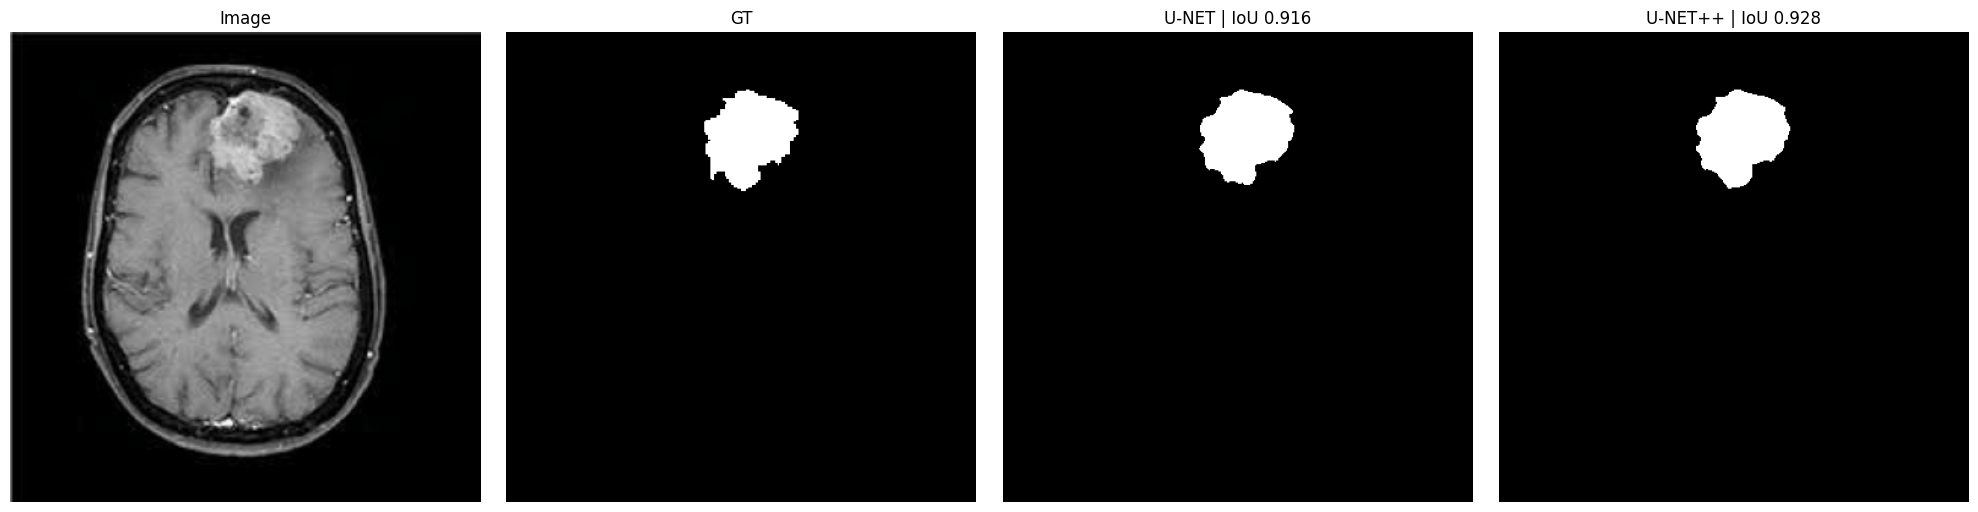

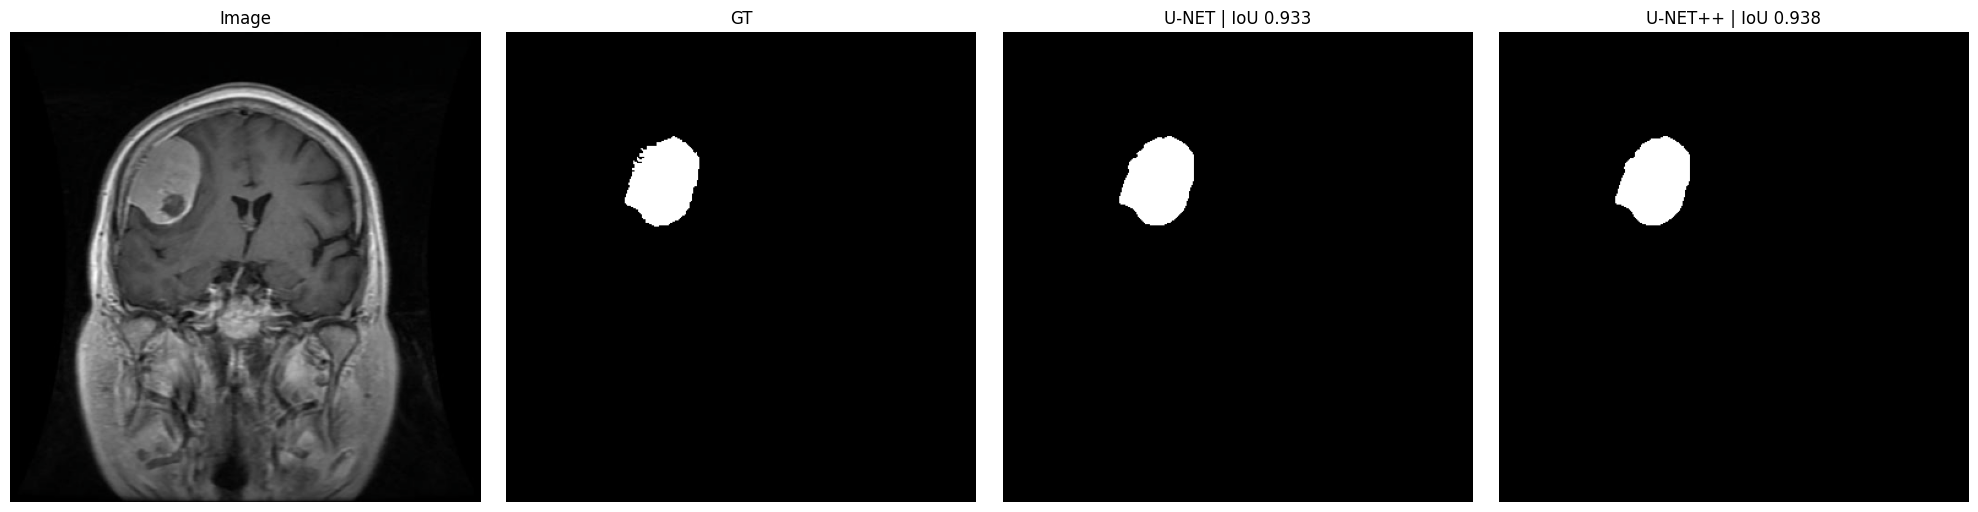

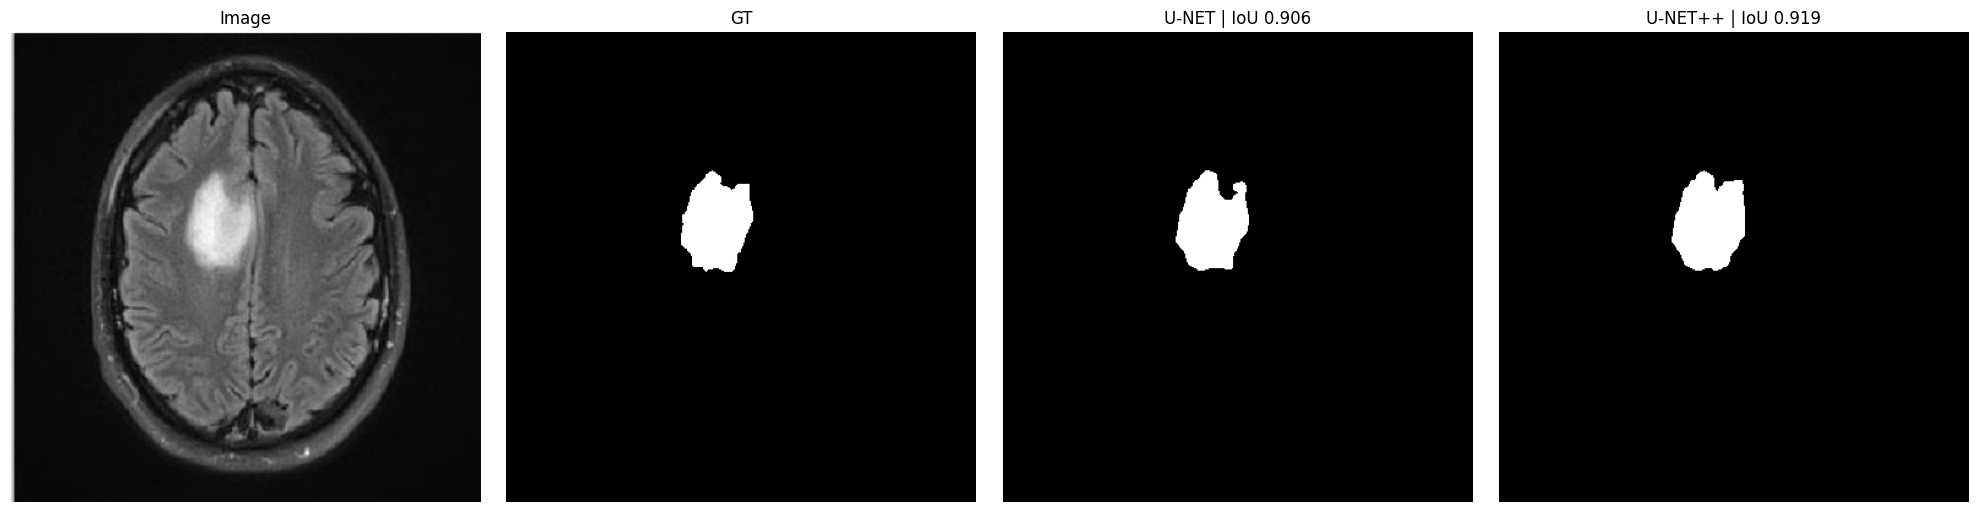

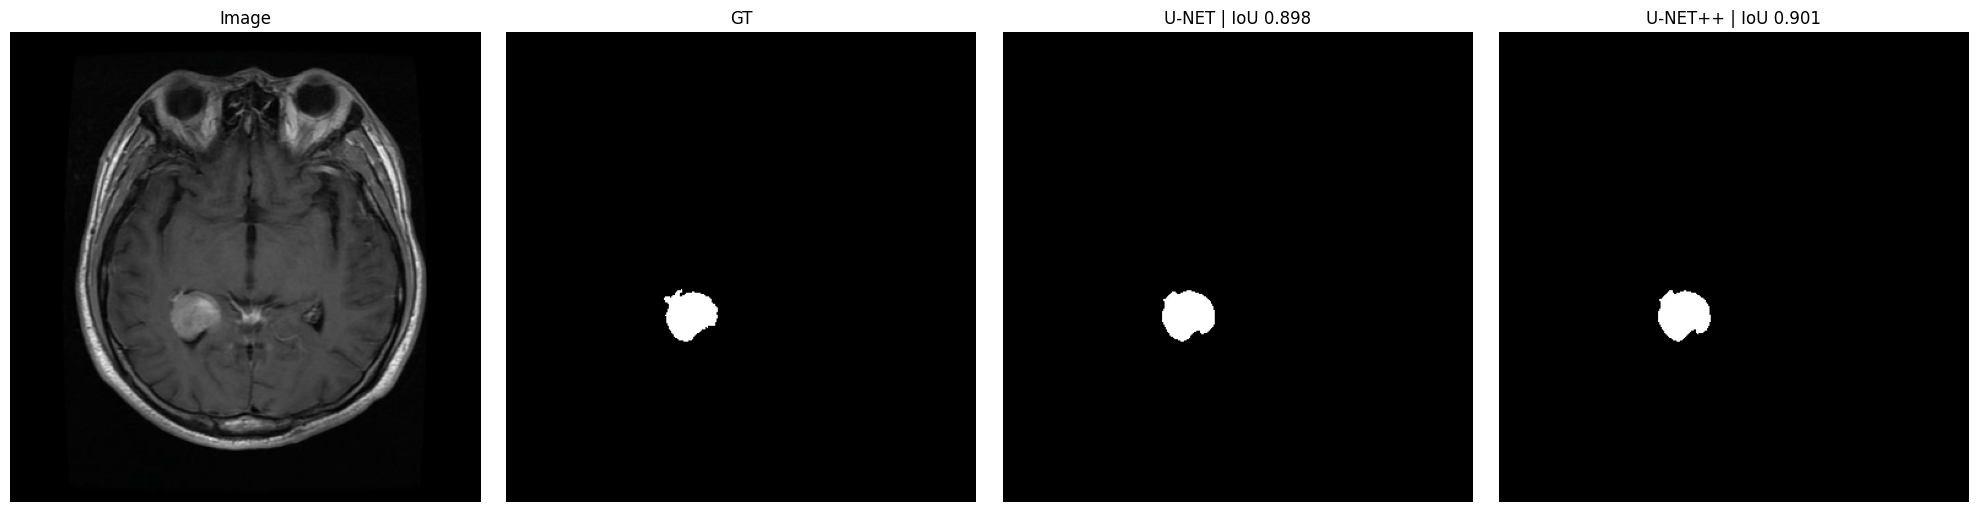

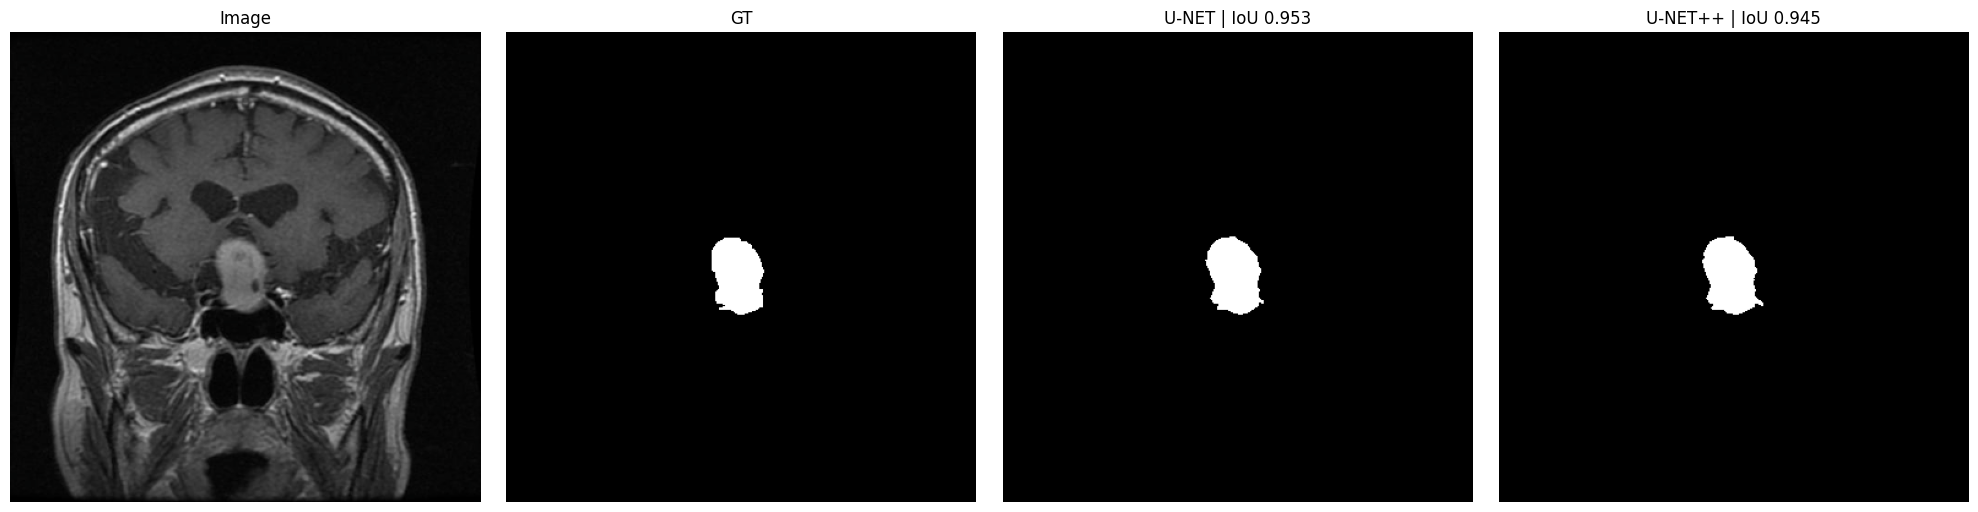

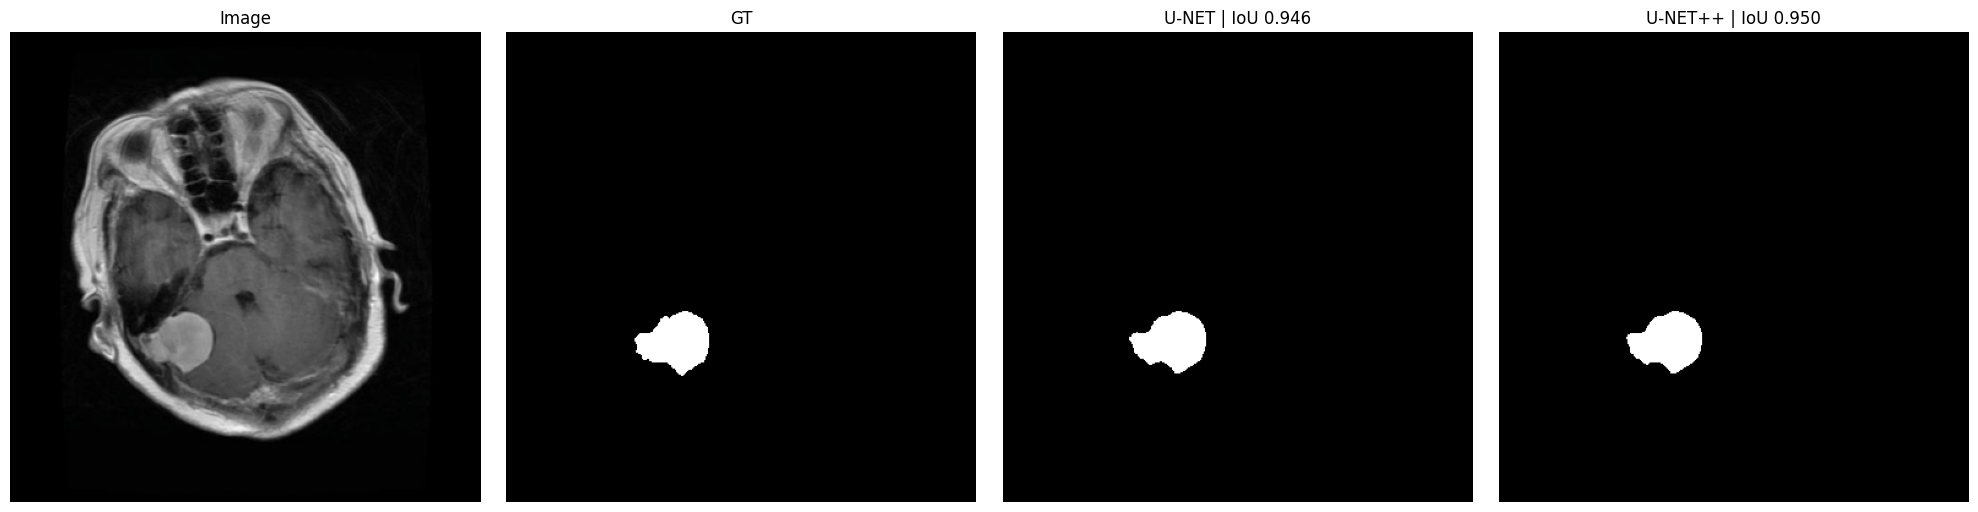

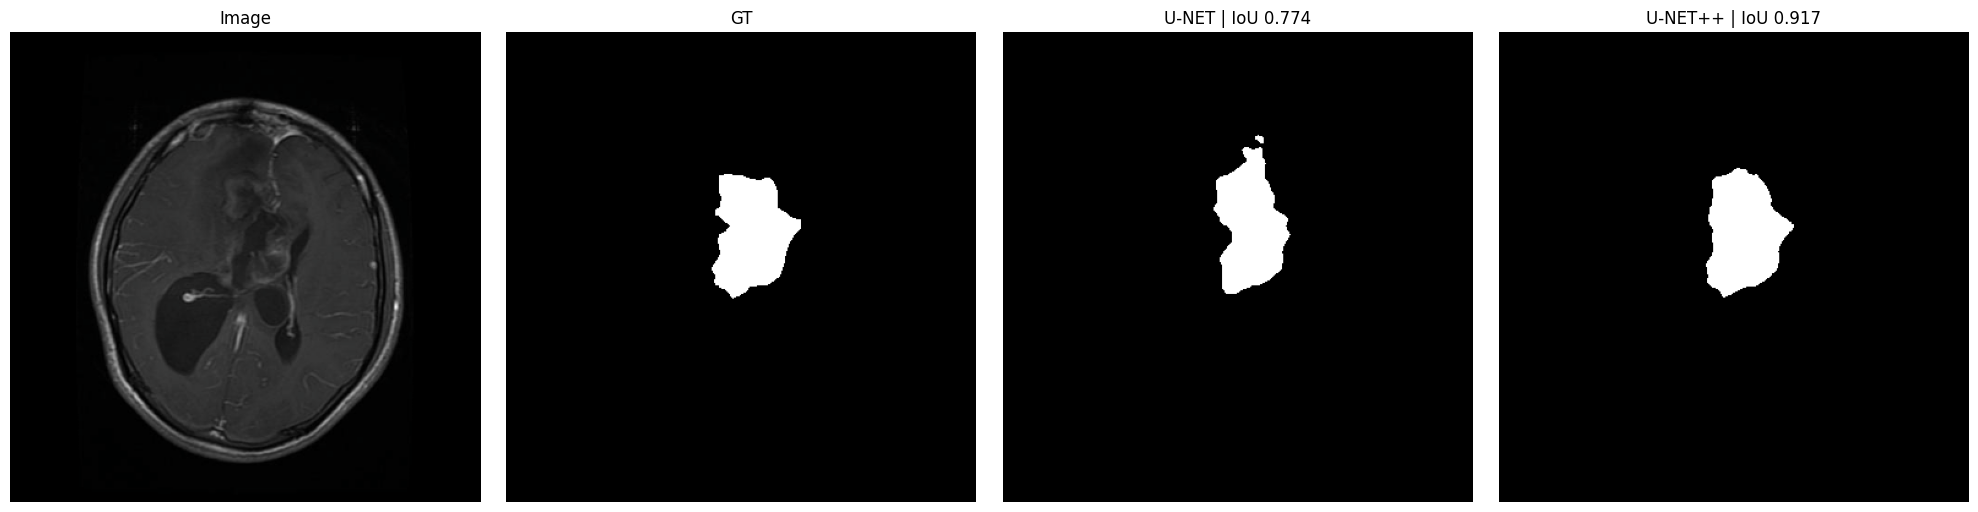

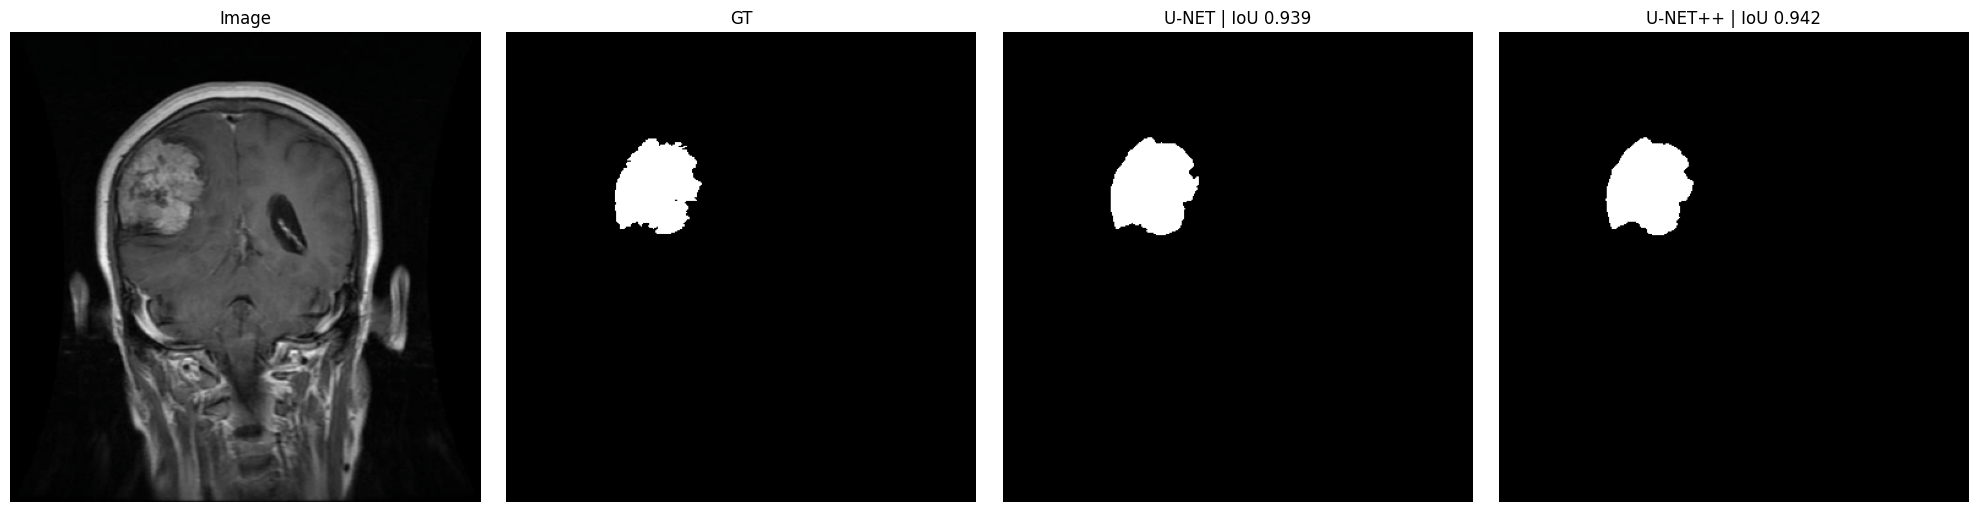

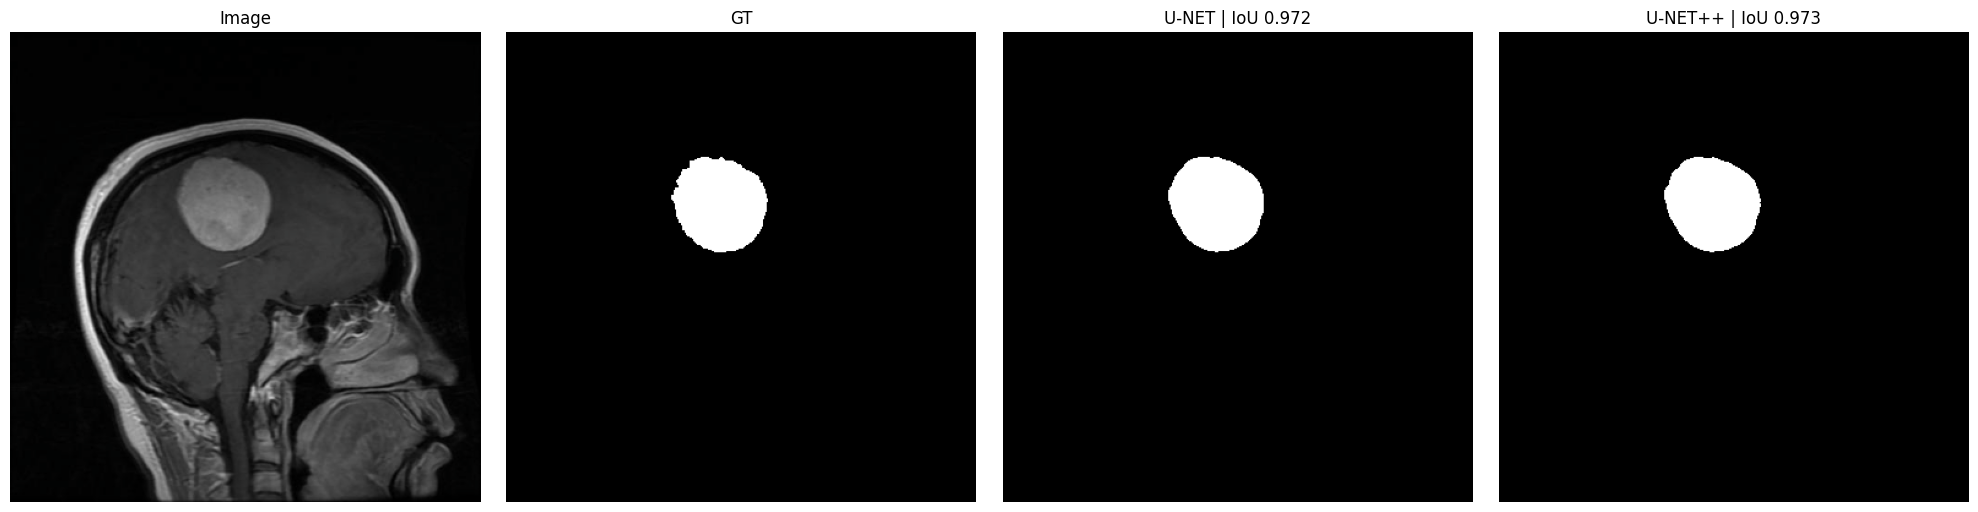

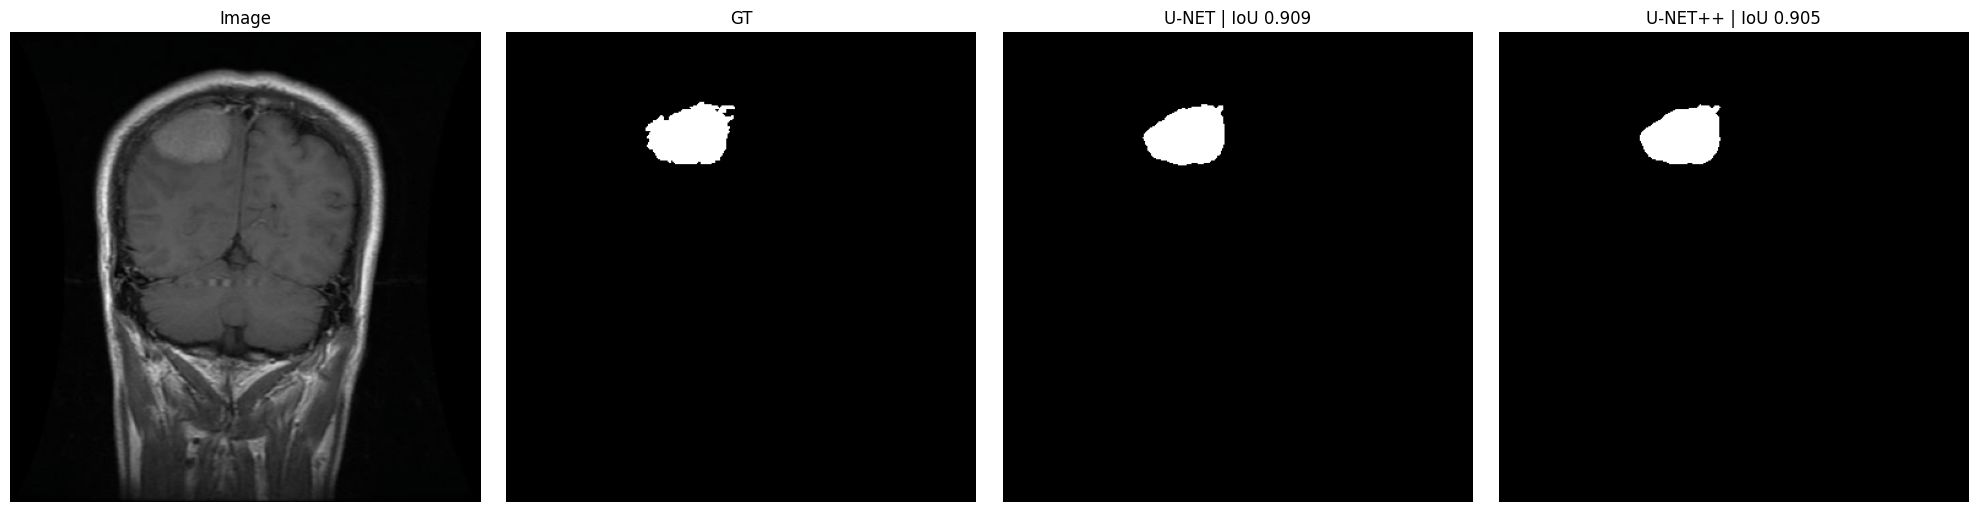

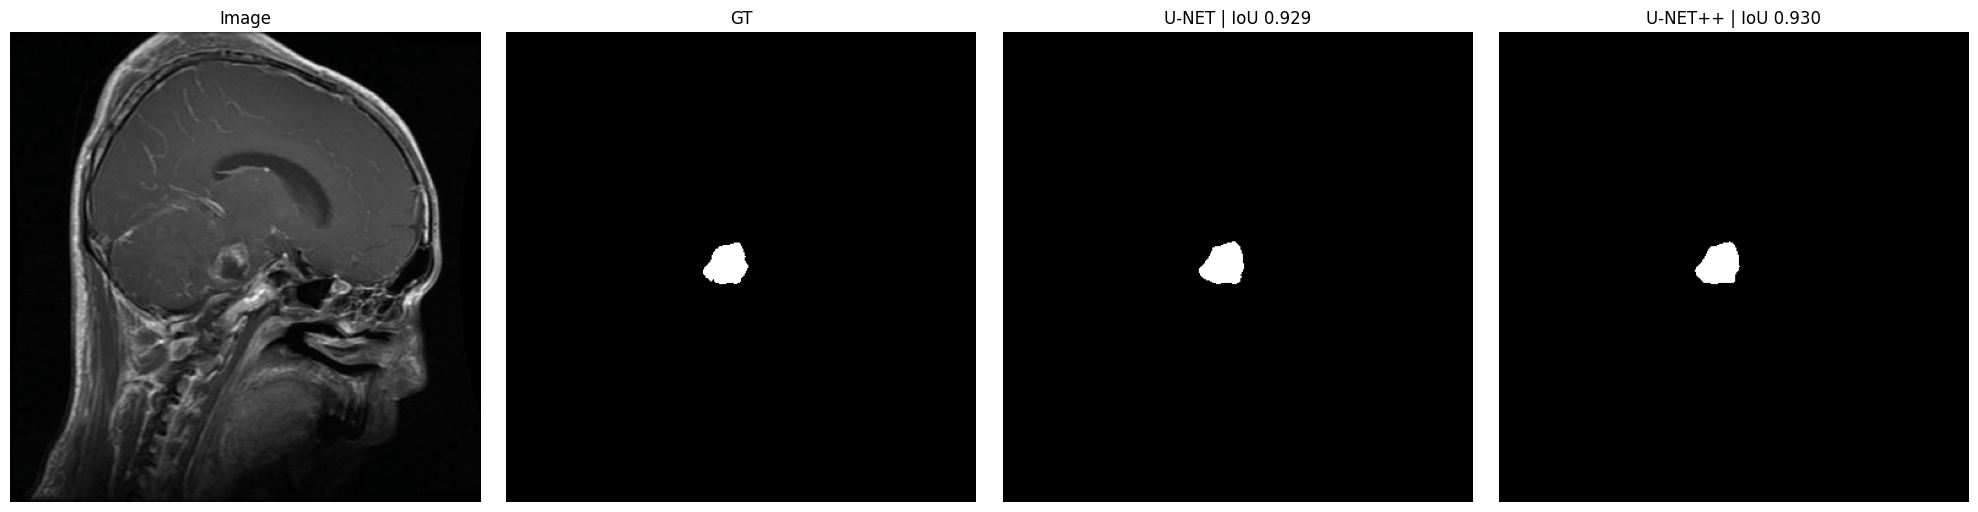

In [37]:
display_preds(unet, unetpp, "U-NET", "U-NET++", val_loader)

In [ ]:
# DISPLAYING THE BEST TEST LOSS AND IOU SCORE OF BOTH MODELS (UNET & UNET++)

import pandas as pd

results = {
    "Model": ["U-Net", "U-Netpp"],
    
    "Best Test IoU": [
        unet_iou,
        unetpp_iou
    ],
    
    "Best Test Loss": [
        unet_loss,
        unetpp_loss
    ]
}

results_df = pd.DataFrame(results)

In [36]:
results_df

,Model,Best Test IoU,Best Test Loss
0,U-Net,0.812019,0.073528
1,U-Netpp,0.821203,0.069753


**THANK YOU!**